#### **Лабораторная работа #1**

Выполнил: Мирасов Константин Владимирович

ИСУ: 466716

Группа: J3212

Вариант: 13

#### Постановка задачи

Рассматривается задача Коши для ОДУ первого порядка:  
$y' = f(x, y), \quad y(x_0) = y_0$

Задано уравнение $y' = -\frac{y}{x} - y^2$ с начальным условием $y(1) = 2$

Численное решение выполняется на отрезке $x \in [1, 2]$. Количество шагов: $n = 20$, поэтому постоянный шаг интегрирования равен $h = \frac{2 - 1}{20} = 0.05$

Для приближённого решения задачи используются следующие численные методы:

- метод Эйлера;
- метод Хойна;
- метод Рунге-Кутты 4-го порядка.

#### Импортируем библиотеки, объявляем необходимые константы и вспомогательные функции

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from typing import Callable
from numpy.typing import NDArray

In [2]:
VARIANT_NUMBER: int = 13
X_START: float = 1.0
Y_START: float = 2.0
X_END: float = 2.0
STEP_COUNT: int = 20
STEP_SIZE: float = (X_END - X_START) / STEP_COUNT

#### Аналитическое решение задачи

Рассмотрим задачу Коши: $y' = -\frac{y}{x} - y^2, \quad y(1)=2$

Перенесём линейное слагаемое в левую часть: $y' + \frac{y}{x} = -y^2$, полученное уравнение является уравнением Бернулли. Введём замену $u = \frac{1}{y}$, тогда $u' = -\frac{y'}{y^2}$

Разделим исходное уравнение на $y^2$: $\frac{y'}{y^2} + \frac{1}{x}\cdot\frac{1}{y} = -1$, с учётом замены получаем линейное уравнение относительно $u$: $u' - \frac{u}{x} = 1$

Интегрирующий множитель для этого уравнения равен $\mu(x)=e^{\int -\frac{1}{x}\,dx}=\frac{1}{x}$, где $x>0$

Умножим уравнение на $\frac{1}{x}$: $\frac{u'}{x} - \frac{u}{x^2} = \frac{1}{x}$, левая часть является производной произведения, поэтому $\left(\frac{u}{x}\right)' = \frac{1}{x}$

Интегрируя, получаем $\frac{u}{x}=\ln x + C$, откуда $u = x(\ln x + C)$

Возвращаясь к переменной $y$, имеем $y = \frac{1}{x(\ln x + C)}$

Используем начальное условие $y(1)=2$: $2 = \frac{1}{1\cdot(\ln 1 + C)} = \frac{1}{C}$, следовательно, $C=\frac{1}{2}$

Итоговое аналитическое решение имеет вид: $\varphi(x)=\frac{1}{x\left(\ln x + \frac{1}{2}\right)}$

In [3]:
def exact_solution(x_value: float) -> float:
    return float(1.0 / (x_value * (np.log(x_value) + 0.5)))

#### Правая часть дифференциального уравнения и построение сетки

Правая часть уравнения имеет вид $f(x, y) = -\frac{y}{x} - y^2$

Численные методы будут применяться на равномерной сетке $x_k = x_0 + k h$

In [5]:
def derivative_function(x_value: float, y_value: float) -> float:
    return -y_value / x_value - y_value ** 2


def build_grid(x_start: float, x_end: float, step_count: int) -> NDArray[np.float64]:
    return np.linspace(x_start, x_end, step_count + 1)

#### Метод Эйлера

Метод Эйлера - это явный численный метод для приближённого решения задачи Коши. На каждом шаге значение функции в следующем узле вычисляется по значению в текущем узле и наклону, заданному правой частью дифференциального уравнения

$
y_{k+1} = y_k + h f(x_k, y_k)
$

Здесь $h$ - шаг интегрирования. В программе он вычисляется как разность соседних узлов сетки: $h = x_{k+1} - x_k$

In [6]:
def solve_euler(
    derivative: Callable[[float, float], float],
    x_values: NDArray[np.float64],
    y_start: float,
) -> NDArray[np.float64]:
    y_values: NDArray[np.float64] = np.zeros(len(x_values), dtype=np.float64)
    y_values[0] = y_start

    for index in range(len(x_values) - 1):
        step_size: float = x_values[index + 1] - x_values[index]
        y_values[index + 1] = y_values[index] + step_size * derivative(x_values[index], y_values[index])

    return y_values

#### Метод Хойна

Метод Хойна сначала делает прогноз следующего значения методом Эйлера, а затем корректирует это значение, используя средний наклон на текущем шаге

$
y_{\text{predict}} = y_k + h f(x_k, y_k)
$

$
y_{k+1} = y_k + \frac{h}{2}\left(f(x_k, y_k) + f(x_{k+1}, y_{\text{predict}})\right)
$


In [8]:
def solve_heun(
    derivative: Callable[[float, float], float],
    x_values: NDArray[np.float64],
    y_start: float,
) -> NDArray[np.float64]:
    y_values: NDArray[np.float64] = np.zeros(len(x_values), dtype=np.float64)
    y_values[0] = y_start

    for index in range(len(x_values) - 1):
        current_x: float = x_values[index]
        next_x: float = x_values[index + 1]
        current_y: float = y_values[index]
        step_size: float = next_x - current_x

        predicted_y: float = current_y + step_size * derivative(current_x, current_y)
        current_slope: float = derivative(current_x, current_y)
        predicted_slope: float = derivative(next_x, predicted_y)

        y_values[index + 1] = current_y + step_size * (current_slope + predicted_slope) / 2

    return y_values

#### Метод Рунге-Кутты 4-го порядка

Метод Рунге-Кутты 4-го порядка использует четыре оценки наклона на каждом шаге интегрирования. Эти оценки комбинируются с весами, чтобы получить более точное приближение значения функции в следующем узле сетки

$
k_1 = f(x_k, y_k)
$

$
k_2 = f\left(x_k + \frac{h}{2}, y_k + \frac{h k_1}{2}\right)
$

$
k_3 = f\left(x_k + \frac{h}{2}, y_k + \frac{h k_2}{2}\right)
$

$
k_4 = f(x_k + h, y_k + h k_3)
$

$
y_{k+1} = y_k + \frac{h}{6}(k_1 + 2k_2 + 2k_3 + k_4)
$

In [9]:
def solve_runge_kutta_4(
    derivative: Callable[[float, float], float],
    x_values: NDArray[np.float64],
    y_start: float,
) -> NDArray[np.float64]:
    y_values: NDArray[np.float64] = np.zeros(len(x_values), dtype=np.float64)
    y_values[0] = y_start

    for index in range(len(x_values) - 1):
        current_x: float = x_values[index]
        current_y: float = y_values[index]
        step_size: float = x_values[index + 1] - current_x

        slope_1: float = derivative(current_x, current_y)
        slope_2: float = derivative(
            current_x + step_size / 2,
            current_y + step_size * slope_1 / 2,
        )
        slope_3: float = derivative(
            current_x + step_size / 2,
            current_y + step_size * slope_2 / 2,
        )
        slope_4: float = derivative(
            current_x + step_size,
            current_y + step_size * slope_3,
        )

        y_values[index + 1] = current_y + step_size * (
            slope_1 + 2 * slope_2 + 2 * slope_3 + slope_4
        ) / 6

    return y_values

#### Построение таблицы решений

Теперь строится равномерная сетка на заданном отрезке и вычисляются значения точного решения, а также приближённые значения, полученные тремя численными методами: методом Эйлера, методом Хойна и методом Рунге-Кутты 4-го порядка. На основе этих данных формируется таблица решений

In [10]:
x_start = X_START
x_end = X_END
y_start = Y_START
step_count = STEP_COUNT

x_values = build_grid(x_start, x_end, step_count)

exact_values = np.array([exact_solution(x_value) for x_value in x_values], dtype=float)

euler_values = solve_euler(derivative_function, x_values, y_start)
heun_values = solve_heun(derivative_function, x_values, y_start)
runge_kutta_4_values = solve_runge_kutta_4(derivative_function, x_values, y_start)

solution_table = pd.DataFrame({
    "x": x_values,
    "Точное решение": exact_values,
    "Метод Эйлера": euler_values,
    "Метод Хойна": heun_values,
    "Метод Рунге-Кутты 4-го порядка": runge_kutta_4_values,
})

solution_table

,x,Точное решение,Метод Эйлера,Метод Хойна,Метод Рунге-Кутты 4-го порядка
0,1.00,2.000000,2.000000,2.000000,2.000000
1,1.05,1.735419,1.700000,1.737274,1.735421
2,1.10,1.527088,1.474548,1.529760,1.527090
3,1.15,1.359201,1.298808,1.362183,1.359204
4,1.20,1.221321,1.157993,1.224356,1.221323
5,1.25,1.106281,1.042696,1.109243,1.106283
6,1.30,1.009007,0.946627,1.011835,1.009009
7,1.35,0.925805,0.865414,0.928472,0.925807
8,1.40,0.853926,0.795914,0.856427,0.853928
9,1.45,0.791285,0.735815,0.793621,0.791286


#### Графики решений

На одном графике сравниваются аналитическое решение и три приближённых решения: методом Эйлера, методом Хойна и методом Рунге-Кутты 4-го порядка

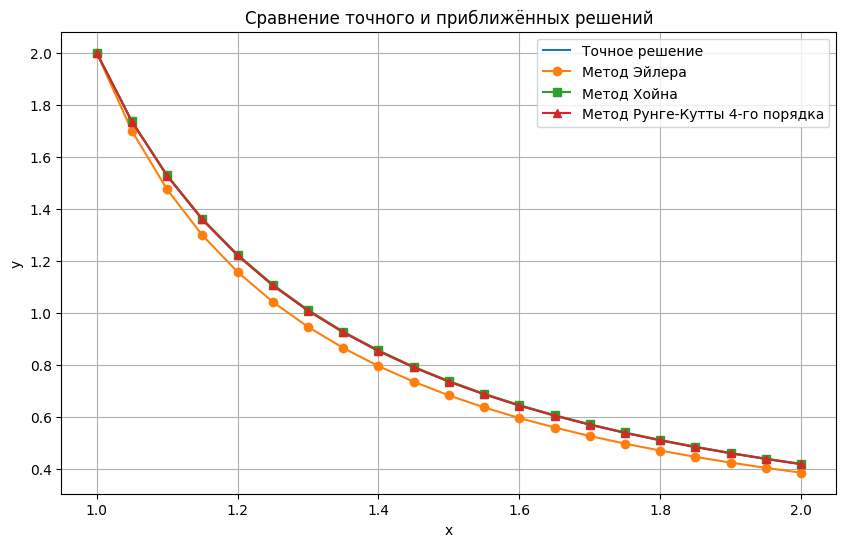

In [11]:
plt.figure(figsize=(10, 6))

plt.plot(x_values, exact_values, label="Точное решение")
plt.plot(x_values, euler_values, marker="o", label="Метод Эйлера")
plt.plot(x_values, heun_values, marker="s", label="Метод Хойна")
plt.plot(x_values, runge_kutta_4_values, marker="^", label="Метод Рунге-Кутты 4-го порядка")

plt.title("Сравнение точного и приближённых решений")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

#### Вычисление абсолютной и относительной погрешности

В соответствии с заданием абсолютная и относительная погрешности для метода с номером $l$ вычисляются по формулам:

$
\Delta_l = \max_{k \in [1:n]} \left|\varphi(x_k) - \widetilde{\varphi}^{l}(x_k)\right|
$

$
\delta_l = \max_{k \in [1:n]} \frac{\left|\varphi(x_k) - \widetilde{\varphi}^{l}(x_k)\right|}{\left|\widetilde{\varphi}^{l}(x_k)\right|}
$

Максимум берётся по $k$ от $1$ до $n$, поэтому начальная точка $x_0$ при вычислении погрешностей не учитывается


In [12]:
def calculate_absolute_error(
    exact_values: NDArray[np.float64],
    approximate_values: NDArray[np.float64],
) -> float:
    exact_values_without_initial_point: NDArray[np.float64] = exact_values[1:]
    approximate_values_without_initial_point: NDArray[np.float64] = approximate_values[1:]

    absolute_errors: NDArray[np.float64] = np.abs(
        exact_values_without_initial_point - approximate_values_without_initial_point
    )

    return float(np.max(absolute_errors))


def calculate_relative_error(
    exact_values: NDArray[np.float64],
    approximate_values: NDArray[np.float64],
) -> float:
    exact_values_without_initial_point: NDArray[np.float64] = exact_values[1:]
    approximate_values_without_initial_point: NDArray[np.float64] = approximate_values[1:]

    absolute_errors: NDArray[np.float64] = np.abs(
        exact_values_without_initial_point - approximate_values_without_initial_point
    )
    absolute_approximate_values: NDArray[np.float64] = np.abs(
        approximate_values_without_initial_point
    )

    with np.errstate(divide="ignore", invalid="ignore"):
        relative_errors: NDArray[np.float64] = np.where(
            absolute_approximate_values != 0.0,
            absolute_errors / absolute_approximate_values,
            np.nan,
        )

    return float(np.nanmax(relative_errors))

#### Таблица погрешностей

Для каждого численного метода вычисляются максимальная абсолютная и максимальная относительная погрешности. Максимальная абсолютная погрешность показывает наибольшее отклонение приближённого решения от точного на узлах сетки, а максимальная относительная погрешность показывает это отклонение относительно приближённого значения

In [16]:
pd.options.display.float_format = "{:.6e}".format

error_table_data = [
    [
        "Метод Эйлера",
        calculate_absolute_error(exact_values, euler_values),
        calculate_relative_error(exact_values, euler_values),
    ],
    [
        "Метод Хойна",
        calculate_absolute_error(exact_values, heun_values),
        calculate_relative_error(exact_values, heun_values),
    ],
    [
        "Метод Рунге-Кутты 4-го порядка",
        calculate_absolute_error(exact_values, runge_kutta_4_values),
        calculate_relative_error(exact_values, runge_kutta_4_values),
    ],
]

error_table = pd.DataFrame(
    error_table_data,
    columns=["Метод", "Абсолютная погрешность", "Относительная погрешность"],
)

error_table

,Метод,Абсолютная погрешность,Относительная погрешность
0,Метод Эйлера,6.358502e-02,8.503059e-02
1,Метод Хойна,3.035290e-03,2.950657e-03
2,Метод Рунге-Кутты 4-го порядка,2.375704e-06,1.903667e-06


#### Вывод

В ходе лабораторной работы была решена задача Коши для дифференциального уравнения $y' = -\frac{y}{x} - y^2$ с начальным условием $y(1)=2$. Для данной задачи было найдено аналитическое решение $\varphi(x)=\frac{1}{x\left(\ln x + \frac{1}{2}\right)}$

Также были реализованы три численных метода: метод Эйлера, метод Хойна и метод Рунге-Кутты 4-го порядка. По построенному графику видно, что все численные решения приближают аналитическое решение на выбранном отрезке

Из таблицы погрешностей следует, что метод Эйлера имеет наибольшую погрешность, метод Хойна даёт более точный результат по сравнению с методом Эйлера, а метод Рунге-Кутты 4-го порядка имеет наименьшую погрешность при выбранном шаге интегрирования. Полученные результаты согласуются с ожидаемой точностью рассмотренных численных методов